## Problem Statement
This notebook aims to reconstruct a full MRI image from undersampled k-space data using a sparse representation in a Gaussian kernel basis. The primary goal is to minimize the difference between the observed undersampled k-space and the k-space of the reconstructed image, effectively recovering the image information lost due to undersampling.

Dicom is the standard file format for medical images and stores pixel data and some other data like scanner settings patient info, slice position etc


tcia_utils nbia is the interface to the cancer imaging archive so theres available datasets we can use

In [ ]:
!pip install tcia_utils pydicom torch matplotlib numpy
import torch
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import os
from tcia_utils import nbia

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Requirements
*   **Input Data:** The model expects 2D DICOM MRI slice data. Specifically, a series of DICOM files .dcm containing pixel data and metadata
*   **Preprocessing:** Data is normalized to a [0, 1] range after clipping outliers and resized to a fixed 256x256 resolution. This preprocessed 2D image serves as the target_image for reconstruction.

Trying to find an available mri collection and downloads a series, a full stack of 2d slices
sorts them by slice order and take the middle scan

In [ ]:
# data = nbia.getSeries(collection="UPENN-GBM")
# if data is None:
#     raise RuntimeError("UPENN-GBM returned no data.")
# print(f"'UPENN-GBM' returned {len(data)} series")

# nbia.downloadSeries(data, number=1, path="./brain_mri")

# # get middle slice
# dcm_files = []
# for root, dirs, files in os.walk("./brain_mri"):
#     for f in files:
#         if f.lower().endswith(".dcm"):
#             dcm_files.append(os.path.join(root, f))

# datasets = [pydicom.dcmread(f) for f in dcm_files]
# datasets.sort(key=lambda ds: ds.InstanceNumber)

# mid = len(datasets) // 2
# ds = datasets[mid]
# pixel_data = ds.pixel_array.astype(np.float32)

# if hasattr(ds, 'RescaleSlope'):
#     pixel_data = pixel_data * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

# print(f"Loaded slice {mid+1}/{len(datasets)}, shape: {pixel_data.shape}")

from PIL import Image
import requests
from io import BytesIO


url = "https://sipi.usc.edu/database/download.php?vol=misc&img=5.1.12"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('L')  #Grayscale

# Convert to tensor and normalize
pixel_data = np.array(img).astype(np.float32) / 255.0
target_image = torch.tensor(pixel_data).unsqueeze(0).unsqueeze(0)
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')
target_image = target_image.squeeze()

Normalize and resize  so that gradient descent works faster:

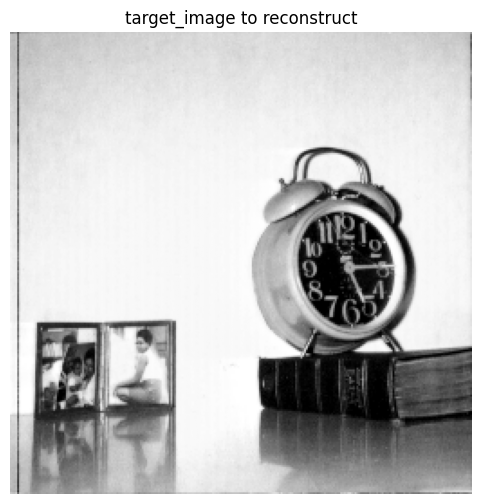

In [ ]:

# Normalize to [0, 1]
# Clip  1st and 99 percentile
p_low, p_high = np.percentile(pixel_data, (1, 99))
pixel_data = np.clip(pixel_data, p_low, p_high)
pixel_data = (pixel_data - p_low) / (p_high - p_low)

# Resize to 256x256 using torch interpolate
target_image = torch.tensor(pixel_data).unsqueeze(0).unsqueeze(0)  # -> [1, 1, H, W]
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')
target_image = target_image.squeeze()  # -> [256, 256]

plt.figure(figsize=(6, 6))
plt.imshow(target_image.numpy(), cmap='gray')
plt.title("target_image to reconstruct")
plt.axis('off')
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

target_image = target_image.to(device)

k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

Using device: cuda
k_full shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([256, 256])
ifft2 function defined.


In [ ]:
# import torch
# import torch.nn.functional as F
# import numpy as np
# import matplotlib.pyplot as plt


# class KernelOptimizer:
#     def __init__(self, target_image, mask, device='cuda', kernel_size=21):
#         assert kernel_size % 2 == 1, "kernel_size must be odd"

#         self.device      = device
#         self.kernel_size = kernel_size
#         self.grid_size   = target_image.shape[0]

#         self.target_image = target_image.to(device)
#         self.mask         = mask.to(device)

#         self.k_full = torch.fft.fftshift(torch.fft.fft2(self.target_image))


#         self.y_obs      = self.k_full * self.mask
#         self.y_obs_scale = torch.abs(self.y_obs).max() + 1e-8  # scalar, saved for reuse
#         self.y_obs_norm  = self.y_obs / self.y_obs_scale



#     def _build_index_matrix(self, centers_x, centers_y):

#         G    = self.grid_size
#         ks   = self.kernel_size
#         half = ks // 2

#         dy, dx = torch.meshgrid(
#             torch.arange(-half, half + 1, device=self.device),
#             torch.arange(-half, half + 1, device=self.device),
#             indexing='ij'
#         )
#         dy = dy.flatten()   # [ks²]
#         dx = dx.flatten()   # [ks²]

#         rows = centers_x.unsqueeze(1) + dy.unsqueeze(0)   # [num_kernels, ks²]
#         cols = centers_y.unsqueeze(1) + dx.unsqueeze(0)   # [num_kernels, ks²]

#         rows = rows.clamp(0, G - 1)
#         cols = cols.clamp(0, G - 1)

#         flat_idx = rows * G + cols   # [num_kernels, ks²]
#         return flat_idx

#     def _build_Phi_fast(self, flat_idx, kernel_weights):
#         """
#         Constructs Phi [G², num_kernels] via a single vectorised scatter_add_.
#         No Python loop — runs in microseconds on GPU.
#         """
#         G           = self.grid_size
#         num_kernels = flat_idx.shape[0]
#         ks_sq       = kernel_weights.shape[0]

#         Phi        = torch.zeros(G * G, num_kernels,
#                                  device=self.device, dtype=torch.float32)
#         kw_expanded = kernel_weights.unsqueeze(0).expand(num_kernels, -1)  # [num_kernels, ks²]

#         Phi.scatter_add_(
#             0,
#             flat_idx.T,       # [ks², num_kernels]
#             kw_expanded.T     # [ks², num_kernels]
#         )
#         return Phi   # [G², num_kernels]



#     def create_and_optimize(self, num_kernels, max_iter=1000, lr=0.01,
#                             return_history=False):
#         G    = self.grid_size
#         ks   = self.kernel_size
#         half = ks // 2

#         centers_x = torch.randint(0, G, (num_kernels,), device=self.device)
#         centers_y = torch.randint(0, G, (num_kernels,), device=self.device)

#         flat_idx = self._build_index_matrix(centers_x, centers_y)


#         xs         = torch.arange(ks, dtype=torch.float32, device=self.device) - half
#         init_gauss = torch.exp(
#             -(xs.unsqueeze(0)**2 + xs.unsqueeze(1)**2) / (2 * 3.0**2)
#         )
#         init_gauss = init_gauss / init_gauss.sum()

#         kernel_weights = init_gauss.flatten().clone().detach().requires_grad_(True)
#         c = (torch.randn(num_kernels, device=self.device) * 0.01).requires_grad_(True)


#         optimizer = torch.optim.Adam([
#             {'params': [c],              'lr': lr},
#             {'params': [kernel_weights], 'lr': lr * 0.5}
#         ])
#         scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#             optimizer, T_max=max_iter, eta_min=1e-5
#         )

#         loss_history = [] if return_history else None

#         for epoch in range(max_iter):
#             optimizer.zero_grad()

#             Phi     = self._build_Phi_fast(flat_idx, kernel_weights)

#             x_recon = (Phi @ c).reshape(G, G)
#             x_recon = x_recon - x_recon.mean()
#             x_recon = x_recon / (x_recon.std() + 1e-8)

#             k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))


#             y_recon_norm = (k_recon * self.mask) / self.y_obs_scale
#             loss         = torch.mean(torch.abs(y_recon_norm - self.y_obs_norm) ** 2)

#             loss.backward()
#             optimizer.step()
#             scheduler.step()

#             if return_history:
#                 loss_history.append(loss.item())
#             if (epoch + 1) % 500 == 0:
#                 print(f"  Epoch {epoch+1}/{max_iter}  loss={loss.item():.6f}")

#         with torch.no_grad():
#             Phi_final   = self._build_Phi_fast(flat_idx, kernel_weights)
#             x_final     = (Phi_final @ c).reshape(G, G)
#             x_final     = x_final - x_final.mean()
#             x_final     = x_final / (x_final.std() + 1e-8)
#             mse         = torch.mean((x_final - self.target_image) ** 2)
#             psnr        = 10 * torch.log10(1.0 / mse)

#         return {
#             'mse':            mse.item(),
#             'psnr':           psnr.item(),
#             'reconstruction': x_final.detach(),
#             'learned_kernel': kernel_weights.detach().reshape(ks, ks).cpu().numpy(),
#             'loss_history':   loss_history,
#         }



#     def grid_search(self, num_kernels_range, max_iter=1000):
#         results = []
#         for num_kernels in num_kernels_range:
#             print(f"\nTesting num_kernels={num_kernels}")
#             out = self.create_and_optimize(num_kernels, max_iter=max_iter)
#             results.append({
#                 'num_kernels':    num_kernels,
#                 'mse':            out['mse'],
#                 'psnr':           out['psnr'],
#                 'learned_kernel': out['learned_kernel'],
#             })
#             print(f"  → MSE: {out['mse']:.6f}  PSNR: {out['psnr']:.2f} dB")
#         return results

#     def bayes_opt(self, n_trials=20, max_iter=500):
#         from skopt import gp_minimize
#         from skopt.space import Integer

#         def objective(params):
#             num_kernels = int(params[0])
#             out = self.create_and_optimize(num_kernels, max_iter=max_iter)
#             return out['mse']

#         space  = [Integer(1000, 20000, name='num_kernels')]
#         result = gp_minimize(objective, space, n_calls=n_trials, random_state=42)

#         print(f"\nBest num_kernels: {int(result.x[0])}")
#         print(f"Best MSE:         {result.fun:.6f}")
#         return result

In [ ]:
class kernelOptimizer:
  def __init__(self, target_image, mask, device= 'cuda'):
    self.target_image = target_image
    self.mask = mask
    self.device = device
    self.k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
    self.y_obs = self.k_full * mask


  def create_and_optimize(self, sigma, num_kernels, max_iter = 1000):
    grid_size = self.target_image.shape[0]
    x = torch.linspace(0, grid_size, grid_size, device = self.device)
    y = torch.linspace(0, grid_size, grid_size, device = self.device)
    grid_x, grid_y = torch.meshgrid(x,y,indexing = 'ij')

    centers_x = torch.randint(0, grid_size, (num_kernels,), device = self.device)
    centers_y = torch.randint(0, grid_size, (num_kernels,), device = self.device)

    basis = []
    for i in range(num_kernels):
      dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
      kernel = torch.exp(-dist_sq / (2 * sigma**2))
      basis.append(kernel.flatten())

    Phi = torch.stack(basis).T.float()

    c = (torch.randn(num_kernels, device = self.device) * 0.01).requires_grad_(True)
    optimizer = torch.optim.Adam([c], lr = 0.01)

    for epoch in range(max_iter):
      optimizer.zero_grad()
      x_recon = (Phi @ c).reshape(grid_size, grid_size)
      k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))
      y_recon = k_recon * self.mask
      loss = torch.mean(torch.abs(y_recon - self.y_obs)**2)
      loss.backward()
      optimizer.step()

    with torch.no_grad():
      final_recon = (Phi @ c).reshape(grid_size, grid_size)
      mse = torch.nn.functional.mse_loss(final_recon, self.target_image)
      psnr = 10 * torch.log10(1.0 /mse)

    return mse.item(), psnr.item()

  def grid_search(self, sigma_range, num_kernels_range):
    results = []
    for sigma in sigma_range:
      for num_kernels in num_kernels_range:
        print(f"Testing sigma = {sigma}, num_kernels = {num_kernels}")
        mse, psnr = self.create_and_optimize(sigma, num_kernels)
        results.append({
            'sigma': sigma,
            'num_kernels': num_kernels,
            'mse': mse,
            'psnr': psnr
        })
        print(f"MSE: {mse:.6f}, PSNR: {psnr:.2f} dB")

    return results

  def bayes_opt(self, n_trials=20):
      from skopt import gp_minimize
      from skopt.space import Real, Integer

      def objective(params):
          sigma, num_kernels = params
          mse, _ = self.create_and_optimize(sigma, int(num_kernels), max_iter=500)
          return mse

      space = [
          Real(1.0, 10.0, name='sigma'),
          Integer(1000, 20000, name='num_kernels')
      ]

      result = gp_minimize(objective, space, n_calls=n_trials, random_state=42)

      print(f"Best parameters found:")
      print(f"  sigma: {result.x[0]:.2f}")
      print(f"  num_kernels: {int(result.x[1])}")
      print(f"  Best MSE: {result.fun:.6f}")

      return result


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

  Epoch 500/10000  loss=0.000029
  Epoch 1000/10000  loss=0.000029
  Epoch 1500/10000  loss=0.000029
  Epoch 2000/10000  loss=0.000029
  Epoch 2500/10000  loss=0.000029
  Epoch 3000/10000  loss=0.000029
  Epoch 3500/10000  loss=0.000029
  Epoch 4000/10000  loss=0.000029
  Epoch 4500/10000  loss=0.000029
  Epoch 5000/10000  loss=0.000029
  Epoch 5500/10000  loss=0.000029
  Epoch 6000/10000  loss=0.000029
  Epoch 6500/10000  loss=0.000029
  Epoch 7000/10000  loss=0.000029
  Epoch 7500/10000  loss=0.000029
  Epoch 8000/10000  loss=0.000029
  Epoch 8500/10000  loss=0.000029
  Epoch 9000/10000  loss=0.000029
  Epoch 9500/10000  loss=0.000029
  Epoch 10000/10000  loss=0.000029

Final MSE:  1.056292
Final PSNR: -0.24 dB


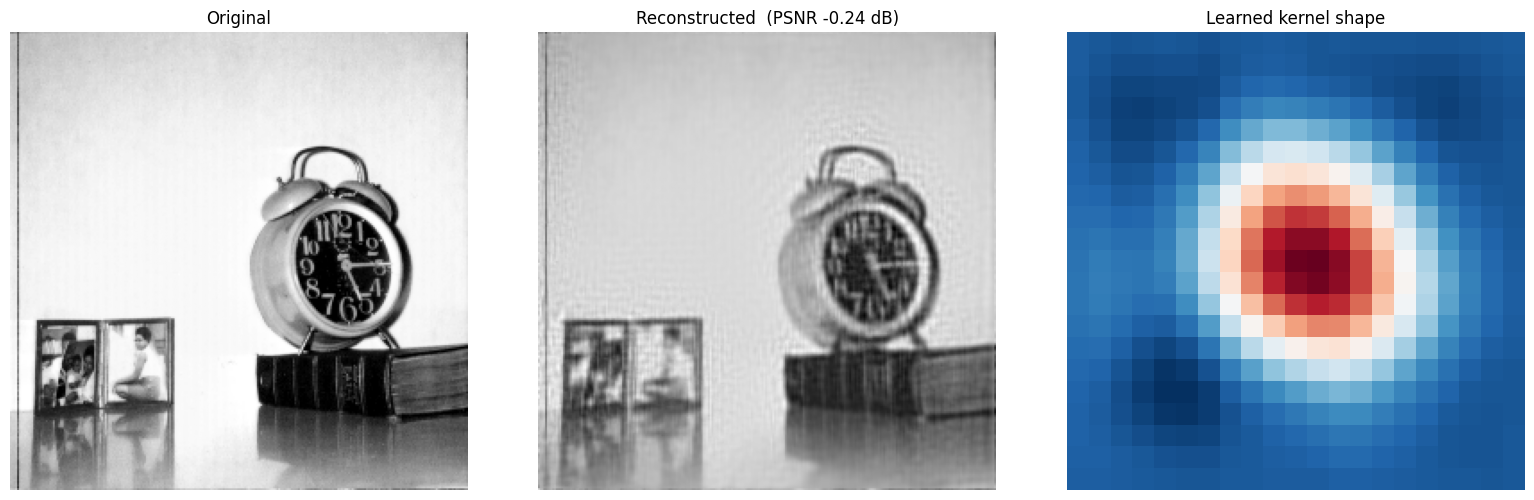

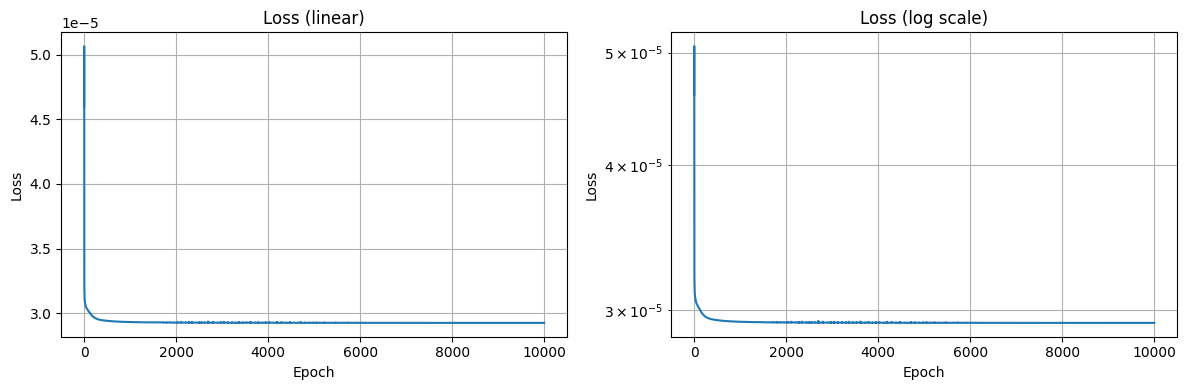

In [ ]:
# # ── Training run ──────────────────────────────────────────────────────

# opt = KernelOptimizer(target_image, mask, device=device, kernel_size=21)

# out = opt.create_and_optimize(
#     num_kernels=8192,
#     max_iter=10000,
#     lr=0.01,
#     return_history=True
# )

# print(f"\nFinal MSE:  {out['mse']:.6f}")
# print(f"Final PSNR: {out['psnr']:.2f} dB")

# # ── Visualise ─────────────────────────────────────────────────────────

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# axes[0].imshow(target_image.cpu().numpy(), cmap='gray')
# axes[0].set_title('Original')
# axes[0].axis('off')

# axes[1].imshow(out['reconstruction'].cpu().numpy(), cmap='gray')
# axes[1].set_title(f"Reconstructed  (PSNR {out['psnr']:.2f} dB)")
# axes[1].axis('off')

# # Show what shape the optimizer actually learned
# axes[2].imshow(out['learned_kernel'], cmap='RdBu_r')
# axes[2].set_title('Learned kernel shape')
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()

# # Loss curves
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].plot(out['loss_history'])
# axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss (linear)')
# axes[0].grid(True)
# axes[1].semilogy(out['loss_history'])
# axes[1].set(xlabel='Epoch', ylabel='Loss', title='Loss (log scale)')
# axes[1].grid(True, which='both')
# plt.tight_layout()
# plt.show()

HYPERPARAMETER OPTIMIZATION

Testing 5 × 2 = 10 combinations...
Testing sigma = 1.0, num_kernels = 8192
MSE: 0.179492, PSNR: 7.46 dB
Testing sigma = 1.0, num_kernels = 16384
MSE: 0.067344, PSNR: 11.72 dB
Testing sigma = 2.0, num_kernels = 8192
MSE: 0.013733, PSNR: 18.62 dB
Testing sigma = 2.0, num_kernels = 16384
MSE: 0.003307, PSNR: 24.81 dB
Testing sigma = 3.0, num_kernels = 8192
MSE: 0.004848, PSNR: 23.14 dB
Testing sigma = 3.0, num_kernels = 16384
MSE: 0.003726, PSNR: 24.29 dB
Testing sigma = 4.0, num_kernels = 8192
MSE: 0.005436, PSNR: 22.65 dB
Testing sigma = 4.0, num_kernels = 16384
MSE: 0.004862, PSNR: 23.13 dB
Testing sigma = 5.0, num_kernels = 8192
MSE: 0.006847, PSNR: 21.65 dB
Testing sigma = 5.0, num_kernels = 16384
MSE: 0.006361, PSNR: 21.96 dB

BEST HYPERPARAMETERS FOUND
  σ (kernel width): 2.0
  num_kernels: 16384
  MSE: 0.003307
  PSNR: 24.81 dB


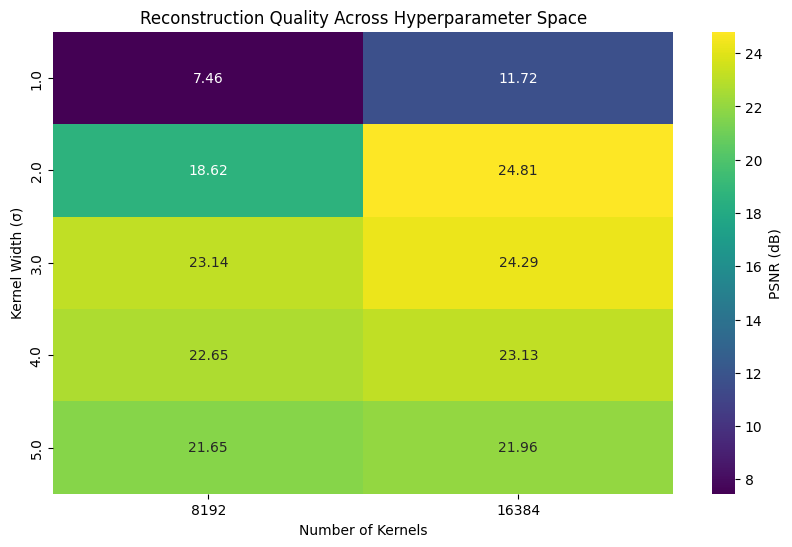


Complete results table:
 sigma  num_kernels      mse      psnr
   1.0         8192 0.179492  7.459545
   1.0        16384 0.067344 11.716979
   2.0         8192 0.013733 18.622220
   2.0        16384 0.003307 24.805625
   3.0         8192 0.004848 23.144408
   3.0        16384 0.003726 24.287016
   4.0         8192 0.005436 22.647568
   4.0        16384 0.004862 23.132089
   5.0         8192 0.006847 21.645286
   5.0        16384 0.006361 21.964830

→ Using σ=2.0, num_kernels=16384 for final reconstruction


In [ ]:

print("HYPERPARAMETER OPTIMIZATION")


hyperparam_opt = kernelOptimizer(target_image, mask, device)

# search space
sigma_range = [1.0, 2.0, 3.0, 4.0, 5.0]
num_kernels_range = [8192, 16384]

# grid search
print(f"\nTesting {len(sigma_range)} × {len(num_kernels_range)} = {len(sigma_range) * len(num_kernels_range)} combinations...")
results = hyperparam_opt.grid_search(sigma_range, num_kernels_range)

# best
best_result = min(results, key=lambda x: x['mse'])

print("\n" + "="*60)
print("BEST HYPERPARAMETERS FOUND")
print("="*60)
print(f"  σ (kernel width): {best_result['sigma']}")
print(f"  num_kernels: {best_result['num_kernels']}")
print(f"  MSE: {best_result['mse']:.6f}")
print(f"  PSNR: {best_result['psnr']:.2f} dB")

# Visualize results
df = pd.DataFrame(results)
pivot_psnr = df.pivot(index='sigma', columns='num_kernels', values='psnr')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_psnr, annot=True, fmt='.2f', cmap='viridis',
            cbar_kws={'label': 'PSNR (dB)'})
plt.title('Reconstruction Quality Across Hyperparameter Space')
plt.xlabel('Number of Kernels')
plt.ylabel('Kernel Width (σ)')
plt.show()

# Table view
print("\nComplete results table:")
print(df.to_string(index=False))

# Save best hyperparameters for final reconstruction
BEST_SIGMA = best_result['sigma']
BEST_NUM_KERNELS = best_result['num_kernels']

print(f"\n→ Using σ={BEST_SIGMA}, num_kernels={BEST_NUM_KERNELS} for final reconstruction")


In [ ]:
def create_kernel_basis(grid_size=256, num_kernels=BEST_NUM_KERNELS, sigma=BEST_SIGMA):
    x = torch.linspace(0, grid_size, grid_size)
    y = torch.linspace(0, grid_size, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

    centers_x = torch.randint(0, grid_size, (num_kernels,))
    centers_y = torch.randint(0, grid_size, (num_kernels,))

    basis = []
    for i in range(num_kernels):
        dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
        kernel = torch.exp(-dist_sq / (2 * sigma**2))
        basis.append(kernel.flatten())

    return torch.stack(basis).T  # [65536 x num_kernels]

Phi = create_kernel_basis()
print(f"Phi shape: {Phi.shape}")

Phi shape: torch.Size([65536, 16384])


In [ ]:
target_image = target_image.to(device)
# Use fftshift to move the low frequencies to the center before masking
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask


y_obs_norm = y_obs / (torch.abs(y_obs).max() + 1e-8)

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

k_full shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([256, 256])
ifft2 function defined.


In [ ]:
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).detach().requires_grad_(True)
learning_rate = .01
optimizer = torch.optim.Adam([c], lr=learning_rate)

print(f"Initialized coefficients 'c' with shape: {c.shape}")
print("Optimizer (Adam) initialized.")

Initialized coefficients 'c' with shape: torch.Size([16384])
Optimizer (Adam) initialized.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move everything first
Phi = Phi.to(device).float()
target_image = target_image.to(device)
mask = mask.to(device)

# Recompute k-space on device
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
y_obs = k_full * mask

# Initialize c ON DEVICE
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).requires_grad_(True)

# Create optimizer AFTER moving c
optimizer = torch.optim.Adam([c], lr=0.01)

Using device: cuda


In [ ]:
loss_history = []
num_epocs = 10000
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=2500, gamma=0.92
)
for epoch in range(num_epocs):
    optimizer.zero_grad()

    #Generate image from basis functions
    x_recon = (Phi @ c).reshape(256, 256)

   #ransform reconstruction to k-space
    k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))

   #apply the same mask to the reconstruction
    y_recon = k_recon * mask

    loss = torch.mean(torch.abs(y_recon - y_obs)**2)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epocs}, Loss: {loss.item():.4f}")
    loss.backward()
    optimizer.step()
    scheduler.step()
    loss_history.append(loss.item())

Epoch 100/10000, Loss: 569.6596
Epoch 200/10000, Loss: 399.1602
Epoch 300/10000, Loss: 339.2094
Epoch 400/10000, Loss: 306.2881
Epoch 500/10000, Loss: 284.6220
Epoch 600/10000, Loss: 268.9473
Epoch 700/10000, Loss: 256.9183
Epoch 800/10000, Loss: 247.3025
Epoch 900/10000, Loss: 239.3786
Epoch 1000/10000, Loss: 232.6923
Epoch 1100/10000, Loss: 226.9425
Epoch 1200/10000, Loss: 221.9221
Epoch 1300/10000, Loss: 217.4821
Epoch 1400/10000, Loss: 213.5145
Epoch 1500/10000, Loss: 209.9343
Epoch 1600/10000, Loss: 206.6807
Epoch 1700/10000, Loss: 203.7029
Epoch 1800/10000, Loss: 200.9642
Epoch 1900/10000, Loss: 198.4233
Epoch 2000/10000, Loss: 196.0628
Epoch 2100/10000, Loss: 193.8651
Epoch 2200/10000, Loss: 191.7936
Epoch 2300/10000, Loss: 189.8662
Epoch 2400/10000, Loss: 188.0237
Epoch 2500/10000, Loss: 186.2706
Epoch 2600/10000, Loss: 184.7449
Epoch 2700/10000, Loss: 183.3169
Epoch 2800/10000, Loss: 181.8800
Epoch 2900/10000, Loss: 180.5414
Epoch 3000/10000, Loss: 179.2313
Epoch 3100/10000, L

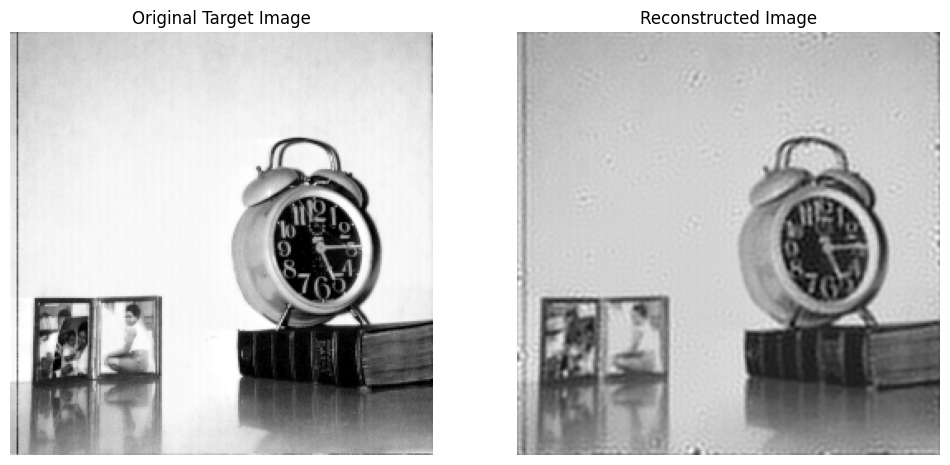

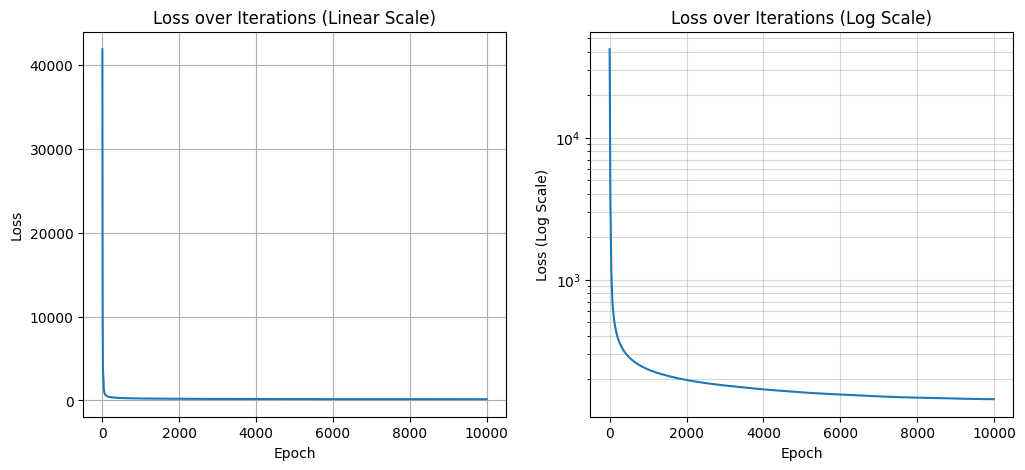

In [ ]:
import matplotlib.pyplot as plt

final_x_recon = (Phi @ c).reshape(256, 256)
reconstructed_image = final_x_recon.cpu().detach().numpy()
target_image_np = target_image.cpu().detach().numpy()

#Visual Comparison: Original vs. Reconstructed
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(target_image_np, cmap='gray')
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

#Optimization Performance: Linear and Log Loss Plots
plt.figure(figsize=(12, 5))

# Standard Linear Plot
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Iterations (Linear Scale)')
plt.grid(True)

# Log Scale Plot
plt.subplot(1, 2, 2)
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss over Iterations (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

## Success Metrics
The performance of the image reconstruction is evaluated using:
*   **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed image and the original target image.
*   **Peak Signal-to-Noise Ratio (PSNR):** A common metric for image quality, providing a quantitative measure of reconstruction fidelity. Higher PSNR values indicate better reconstruction quality.

In [ ]:
import torch.nn.functional as F

mse = F.mse_loss(final_x_recon.flatten(), target_image.flatten())
psnr = 10 * torch.log10(1.0 / mse)
print(f"MSE: {mse.item():.6f}")
print(f"PSNR: {psnr.item():.2f} dB")

MSE: 0.002190
PSNR: 26.60 dB


## Resource Monitoring


*   System Ram - 7.8/12.7 GB
*   GPU Ram - 4.2/15.0 GB

*   Disk - 38.8/112.6 GB





## Known Limitations
*   **Basis Function Choice:** The current implementation uses fixed-size Gaussian kernels. The choice of sigma and num_kernels is empirical and may not be optimal for all image types or reconstruction tasks.
*   **Undersampling Pattern:** The mask for k-space undersampling is a simple central region. More advanced undersampling patterns are not explored.
*   **Computational Cost:** For very large images or a significantly higher number of basis functions, the matrix multiplication Phi @ c can become computationally intensive.
*   **Lack of Regularization:** The current objective function only minimizes the k-space error. Incorporating regularization  could improve reconstruction quality and noise suppression.

## Next Steps
*   **Explore different basis functions:** Investigate other sparse representations beyond Gaussian kernels.
*   **Implement image-domain regularization:** Add Total Variation (TV) or other regularization terms to the loss function to improve reconstruction quality and noise robustness.
*   **Dynamic mask generation:** Implement methods to generate more complex or adaptive k-space undersampling masks.
*   **Hyperparameter tuning:** Systematically tune parameters like sigma, num_kernels, learning_rate, and regularization weights.
*   **Quantitative evaluation:** Perform reconstructions on a larger dataset and compare results with other MRI reconstruction methods.